#TAREA 4-5
## Leonardo Garcia Muñoz

- Realizar análisis con MLlib de pyspark a tu conjunto de datos.

In [1]:
from pyspark.sql import SparkSession
from pyspark import SparkContext

spark = SparkSession.builder \
    .appName("Tarea4BIGDATA") \
    .getOrCreate()

In [2]:
df = spark.read.csv(
    "/content/youtube_bigdata_comments_dataset_2.csv",
    header=True,
    inferSchema=False,
    multiLine=True,
    quote='"',
    escape='"',
    mode="PERMISSIVE")

In [3]:
df.show(5)
df.printSchema()

+--------------------+--------------+-----------+--------------------+--------------------+--------------------+-----+--------------------+-----------+
|          channel_id| channel_title|   video_id|         video_title|              author|             comment|likes|        published_at|reply_count|
+--------------------+--------------+-----------+--------------------+--------------------+--------------------+-----+--------------------+-----------+
|UCRZpxmNB22q_jXcL...|Conversaciones|IffJxvWNUiM|Contactar a Leo M...|@omarvalenteplaza...|mañana nuevo capi...|    0|2026-03-08T22:32:07Z|          0|
|UCRZpxmNB22q_jXcL...|Conversaciones|cxrvVgQ4bt4|Así se LOGRÓ el P...| @jeffersonsilva1089|Soy de Nicaragua ...|    0|2026-03-08T19:13:35Z|          0|
|UCRZpxmNB22q_jXcL...|Conversaciones|cxrvVgQ4bt4|Así se LOGRÓ el P...|  @JorgeDeLara-xg3uw|Adrian solo fue d...|    0|2026-03-08T16:09:53Z|          0|
|UCRZpxmNB22q_jXcL...|Conversaciones|cxrvVgQ4bt4|Así se LOGRÓ el P...|@miguelangelherre.

In [4]:
#Aplicamos las modificaciones hechas en la tarea anterior
from pyspark.sql.functions import col, lower, trim
df = df.withColumn("comment", lower(trim(col("comment"))))

In [5]:
from pyspark.sql.functions import length,to_date,when, hour
df = df.withColumn("longitud_caracteres", length(col("comment")))

df = df.withColumn(
    "popularidad",when(col("likes") > 1300, "viral").when(col("likes") > 130, "alta").when(col("likes") > 13, "media").otherwise("baja"))

df = df.withColumn("fecha_limpia", to_date(col("published_at")))
df = df.withColumn("hora_publicacion", hour(col("published_at")))

In [6]:
df.show(15)

+--------------------+--------------+-----------+--------------------+--------------------+--------------------+-----+--------------------+-----------+-------------------+-----------+------------+----------------+
|          channel_id| channel_title|   video_id|         video_title|              author|             comment|likes|        published_at|reply_count|longitud_caracteres|popularidad|fecha_limpia|hora_publicacion|
+--------------------+--------------+-----------+--------------------+--------------------+--------------------+-----+--------------------+-----------+-------------------+-----------+------------+----------------+
|UCRZpxmNB22q_jXcL...|Conversaciones|IffJxvWNUiM|Contactar a Leo M...|@omarvalenteplaza...|mañana nuevo capi...|    0|2026-03-08T22:32:07Z|          0|                 39|       baja|  2026-03-08|              22|
|UCRZpxmNB22q_jXcL...|Conversaciones|cxrvVgQ4bt4|Así se LOGRÓ el P...| @jeffersonsilva1089|soy de nicaragua ...|    0|2026-03-08T19:13:35Z|     

In [ ]:
#Ahora si viene lo chido...


## El objetivo de este analisis es la clasificacion de tipos de comentarios y poder tener diferentes clusters, como aquellos comentarios cortos pero con muchas interacciones, aquellos largos que no tienen casi interacciones, etc.

In [7]:
from pyspark.sql.functions import col

df = df.withColumn("likes", col("likes").cast("int"))#convertimos las columnas porque luego salen errores
df = df.withColumn("reply_count", col("reply_count").cast("int"))
df = df.withColumn("longitud_caracteres", col("longitud_caracteres").cast("int"))
df = df.withColumn("hora_publicacion", col("hora_publicacion").cast("int"))

In [8]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover

In [9]:
df_ml = df.select(
    "comment",
    "likes",
    "reply_count",
    "longitud_caracteres",
    "hora_publicacion"
).dropna() #nos traemos solo ciertas columnas, no todas, haciendo un tipo embudo de las columnas que realmente nos serviran para el analisis

#Tokenizer nos ayuda a separar el texto en palabras
tokenizer = Tokenizer(inputCol="comment", outputCol="words")
df_words = tokenizer.transform(df_ml)

#StopWordsRemover nos elimina palabras comunes (ej: "el", "la", "y")
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
df_filtered = remover.transform(df_words)

In [10]:
from pyspark.ml.feature import HashingTF, IDF
hashingTF = HashingTF(inputCol="filtered_words", outputCol="text_features", numFeatures=1000)#HashingTF convierte palabras en vectores numéricos
df_featurized = hashingTF.transform(df_filtered)

idf = IDF(inputCol="text_features", outputCol="tfidf_features")#IDF da peso a palabras importantes (menos comunes)
idf_model = idf.fit(df_featurized)
df_tfidf = idf_model.transform(df_featurized)

In [11]:
from pyspark.ml.feature import VectorAssembler

In [12]:
#VectorAssembler nos junta todas las variables en un solo vector "features"
assembler = VectorAssembler(inputCols=[
        "tfidf_features",
        "likes",
        "reply_count",
        "longitud_caracteres",
        "hora_publicacion"],outputCol="features")

df_final = assembler.transform(df_tfidf)

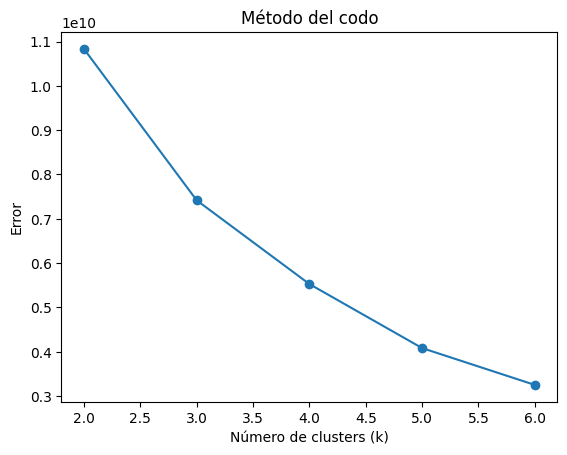

In [16]:
#metodo del codo para poder aplicar KMeans
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt
cost = []
#distintos valores de k
k_values = list(range(2, 7))# de 2 a 6 clusters

for k in k_values:
    kmeans = KMeans(k=k, seed=42, featuresCol="features")
    model = kmeans.fit(df_final)
    #trainingCost
    cost.append(model.summary.trainingCost)
plt.figure()
plt.plot(k_values, cost, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Error")
plt.title("Método del codo")
plt.savefig("metodo_codo.jpg", dpi=300, bbox_inches='tight')
plt.show()

In [21]:
#Ahora ya nos traemos a aplicar K-Means
#ahora si listos para agrupar los datos en clusters
kmeans = KMeans(k=4, seed=42) #4 clusters

In [22]:
#Entrenamos el modelo
model = kmeans.fit(df_final)

In [23]:
#Aplicamos el modelo a los datos
df_result = model.transform(df_final)

In [24]:
df_result.groupBy("prediction").count().show()
#imprimimos de manera agrupada un "count(comentarios)" para cada cluster

+----------+------+
|prediction| count|
+----------+------+
|         1|     3|
|         3|  5318|
|         2|    92|
|         0|167956|
+----------+------+



In [25]:
from pyspark.sql.functions import avg
#nos traemos el promedio de likes de los cluster y el promedio de longitud
df_result.groupBy("prediction").agg(
    avg("likes").alias("avg_likes"),
    avg("longitud_caracteres").alias("avg_longitud")
).show()

+----------+------------------+------------------+
|prediction|         avg_likes|      avg_longitud|
+----------+------------------+------------------+
|         1|43023.666666666664|              45.0|
|         3|15.134072959759308| 679.5231289958631|
|         2| 8046.597826086957|119.51086956521739|
|         0|  7.35870108838029| 74.22254042725476|
+----------+------------------+------------------+



In [ ]:
#Okey pero ahora haciendo un analisis mas a profundidad

In [26]:
df_result.filter(col("prediction") == 0) \
    .select("comment", "likes", "longitud_caracteres") \
    .show(20, truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+-------------------+
|comment                                                                                                                                                                                                                                                                                                                  |likes|longitud_caracteres|
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-

In [27]:
df_result.filter(col("prediction") == 1) \
    .select("comment", "likes", "longitud_caracteres") \
    .show(10, truncate=False)

+---------------------------------------------------------------+-----+-------------------+
|comment                                                        |likes|longitud_caracteres|
+---------------------------------------------------------------+-----+-------------------+
|se acordó de la contraseña del canal                           |37685|36                 |
|se acordó de la contraseña del canal                           |45738|36                 |
|jordi es como mi papa, se va por meses y regresa para traumarme|45648|63                 |
+---------------------------------------------------------------+-----+-------------------+



In [28]:
df_result.filter(col("prediction") == 2) \
    .select("comment", "likes", "longitud_caracteres") \
    .show(20, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+-------------------+
|comment                                                                                                                                                                                                                                                                                                                                                            

In [29]:
df_result.filter(col("prediction") == 3) \
    .select("comment", "likes", "longitud_caracteres") \
    .show(20, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+-------------------+
|comment                                                                                                                                                 

In [ ]:
#Cluster 0 → Comentarios simples con nulas o muy pocas interacciones
#Cluster 1 → Comentarios randoms pero virales
#Cluster 2 → Comentarios bastante elaborados y con muchos likes
#Cluster 3 → Comentarios muy elaborados y largos pero con muy pocas interacciones

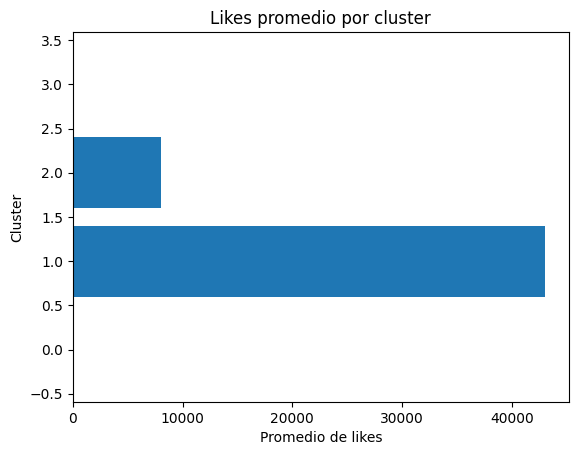

In [ ]:
#Obtenemos la graficas para el reporte
import matplotlib.pyplot as plt
from pyspark.sql.functions import avg

df_likes = df_result.groupBy("prediction").agg(
    avg("likes").alias("avg_likes")
).toPandas()

plt.figure()
plt.barh(df_likes["prediction"], df_likes["avg_likes"])
plt.xlabel("Promedio de likes")
plt.ylabel("Cluster")
plt.title("Likes promedio por cluster")
plt.savefig("grafica_likes_cluster.jpg", dpi=300, bbox_inches='tight')
plt.show()

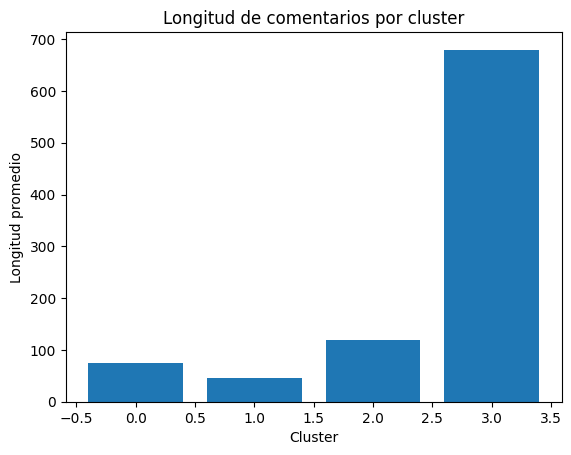

In [ ]:
df_length = df_result.groupBy("prediction").agg(
    avg("longitud_caracteres").alias("avg_length")
).toPandas()

plt.figure()
plt.bar(df_length["prediction"], df_length["avg_length"])
plt.xlabel("Cluster")
plt.ylabel("Longitud promedio")
plt.title("Longitud de comentarios por cluster")
plt.savefig("grafica2.jpg", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

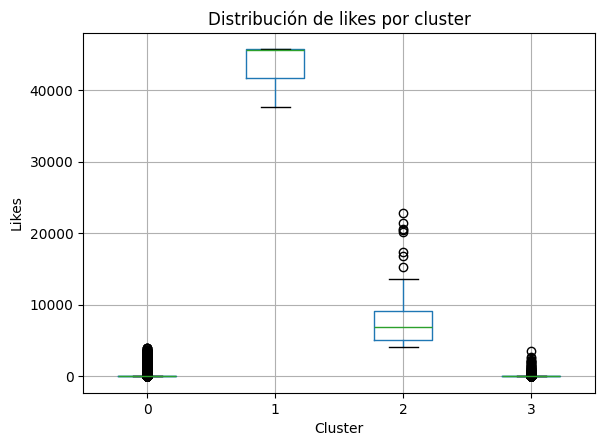

In [ ]:
df_box = df_result.select("prediction", "likes").toPandas()

plt.figure()
df_box.boxplot(column="likes", by="prediction")
plt.xlabel("Cluster")
plt.ylabel("Likes")
plt.title("Distribución de likes por cluster")
plt.suptitle("")
plt.savefig("grafica3.jpg", dpi=300, bbox_inches='tight')
plt.show()

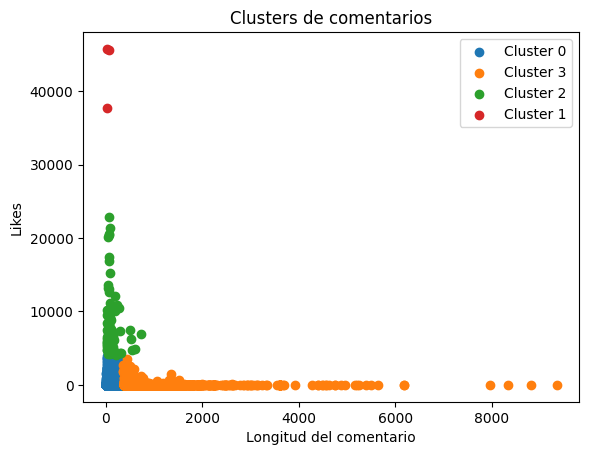

In [ ]:
df_scatter = df_result.select(
    "prediction", "likes", "longitud_caracteres"
).toPandas()

plt.figure()

for cluster in df_scatter["prediction"].unique():
    subset = df_scatter[df_scatter["prediction"] == cluster]
    plt.scatter(
        subset["longitud_caracteres"],
        subset["likes"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Longitud del comentario")
plt.ylabel("Likes")
plt.title("Clusters de comentarios")
plt.legend()
plt.savefig("grafica4.jpg", dpi=300, bbox_inches='tight')
plt.show()

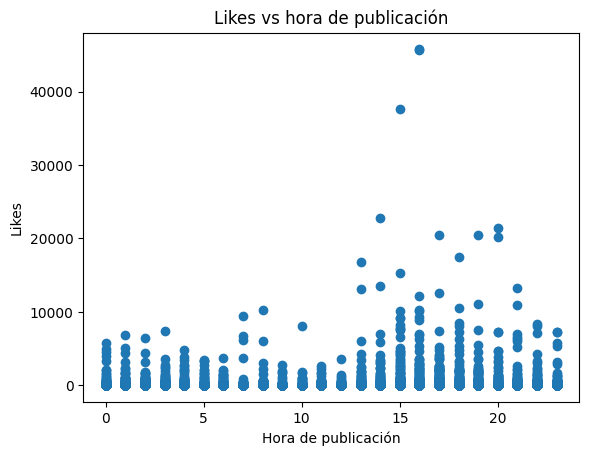

In [ ]:
df_time = df_result.select(
    "hora_publicacion", "likes"
).toPandas()

plt.figure()
plt.scatter(df_time["hora_publicacion"], df_time["likes"])

plt.xlabel("Hora de publicación")
plt.ylabel("Likes")
plt.title("Likes vs hora de publicación")
plt.savefig("grafica5.jpg", dpi=300, bbox_inches='tight')
plt.show()

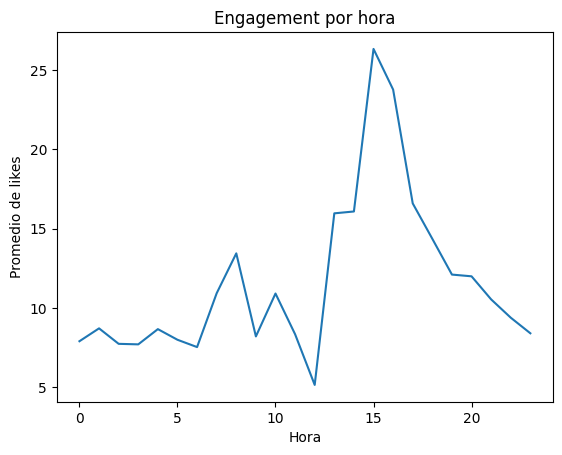

In [ ]:
from pyspark.sql.functions import avg
df_hour = df_result.groupBy("hora_publicacion").agg(
    avg("likes").alias("avg_likes")
).orderBy("hora_publicacion").toPandas()

plt.figure()
plt.plot(df_hour["hora_publicacion"], df_hour["avg_likes"])
plt.xlabel("Hora")
plt.ylabel("Promedio de likes")
plt.title("Engagement por hora")
plt.savefig("grafica6.jpg", dpi=300, bbox_inches='tight')
plt.show()

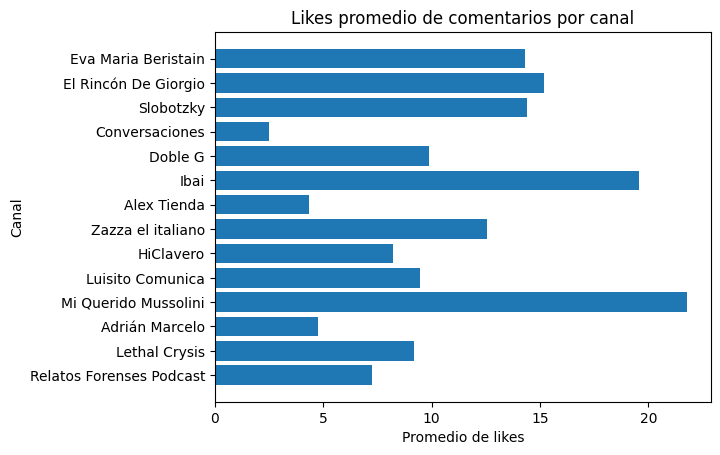

In [36]:
#Agregaremos unos graficos para la parte inicial del reporte
from pyspark.sql.functions import avg

df_channel = df.groupBy("channel_title").agg(
    avg("likes").alias("avg_likes")
).toPandas()

plt.figure()
plt.barh(df_channel["channel_title"], df_channel["avg_likes"])
plt.xlabel("Promedio de likes")
plt.ylabel("Canal")
plt.title("Likes promedio de comentarios por canal")

plt.savefig("grafica10.jpg", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 1200x600 with 0 Axes>

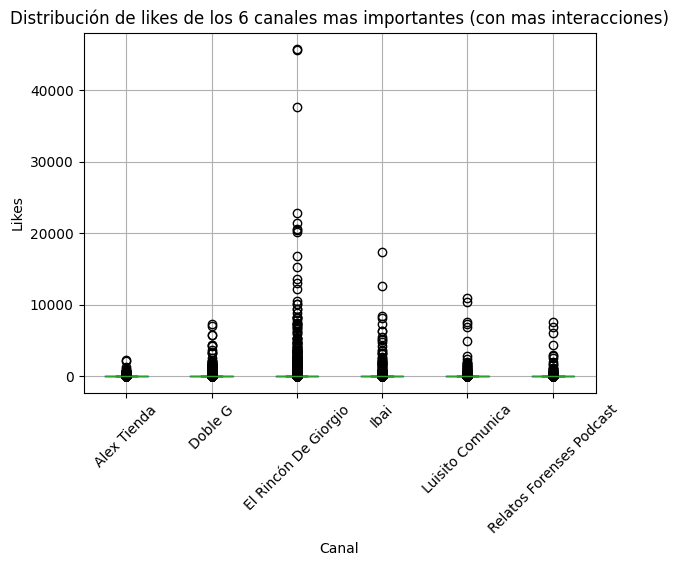

In [39]:
from pyspark.sql.functions import count

top_channels = df.groupBy("channel_title") \
    .agg(count("*").alias("total")) \
    .orderBy("total", ascending=False) \
    .limit(6)

top_list = [row["channel_title"] for row in top_channels.collect()]

df_filtered = df.filter(col("channel_title").isin(top_list))

df_filtered_box_channel = df_filtered.select("channel_title", "likes").toPandas()

plt.figure(figsize=(12, 6))
df_filtered_box_channel.boxplot(column="likes", by="channel_title")
plt.xlabel("Canal")
plt.ylabel("Likes")
plt.title("Distribución de likes de los 6 canales mas importantes (con mas interacciones)")
plt.suptitle("")
plt.xticks(rotation=45)
plt.savefig("grafica11.jpg", dpi=300, bbox_inches='tight')
plt.show()

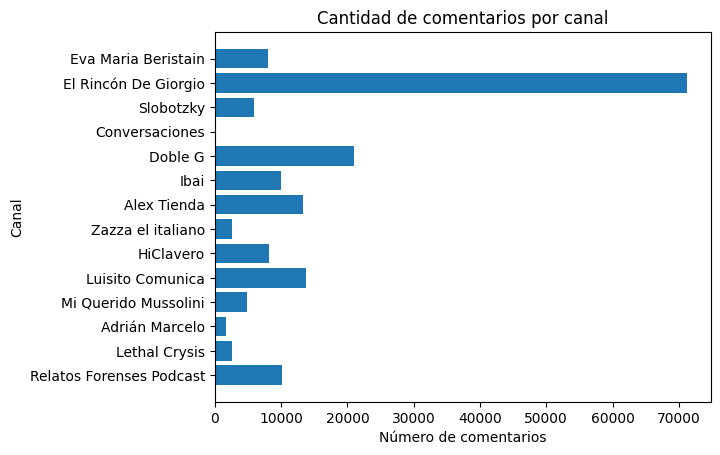

In [35]:
df_count = df.groupBy("channel_title").count().toPandas()

plt.figure()
plt.barh(df_count["channel_title"], df_count["count"])
plt.xlabel("Número de comentarios")
plt.ylabel("Canal")
plt.title("Cantidad de comentarios por canal")

plt.savefig("grafica12.jpg", dpi=300, bbox_inches='tight')
plt.show()

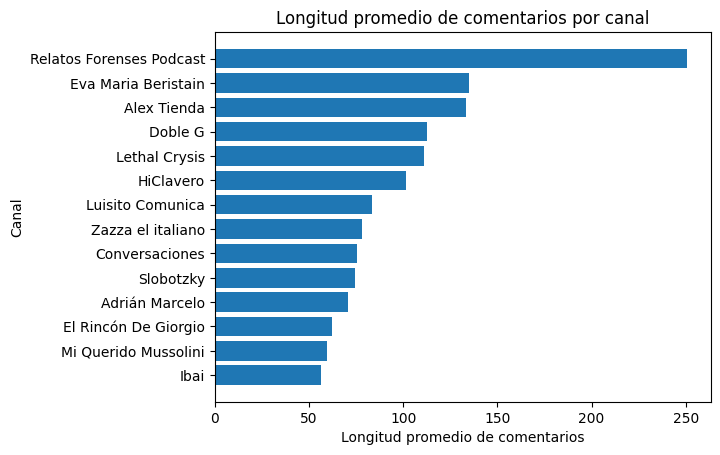

In [41]:
#longitud promedio por canal
df_len_channel = df.groupBy("channel_title").agg(
    avg("longitud_caracteres").alias("avg_longitud")
).toPandas()
df_len_channel = df_len_channel.sort_values("avg_longitud")

plt.figure()
plt.barh(df_len_channel["channel_title"], df_len_channel["avg_longitud"])
plt.xlabel("Longitud promedio de comentarios")
plt.ylabel("Canal")
plt.title("Longitud promedio de comentarios por canal")

plt.savefig("grafica13.jpg", dpi=300, bbox_inches='tight')
plt.show()